In [1]:
!pip install arxiv scholarly

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached arrow-1.4.0-py3-none-any.whl.metadata (7.7 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with stat


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Empiezo la segunda hipótesis importando la librería arxiv y viendo qué contiene y con qué puedo trabajar

In [9]:
# importo las librerías necesarias

import arxiv
import pandas as pd
import time

cliente = arxiv.Client(page_size=10, delay_seconds=3, num_retries=3) # abro la conexión con arxiv para obtener los datos de su API

queries = [
    "simulation hypothesis physics",
    "simulated universe cosmology",
    "digital physics reality",
    "Nick Bostrom simulation argument",
    "simulation argument philosophy"
]

todos_resultados = []

for query in queries:
    busqueda = arxiv.Search(
        query=query,
        max_results=50,
        sort_by=arxiv.SortCriterion.Relevance
    )
    for paper in cliente.results(busqueda):
        todos_resultados.append({
            "titulo": paper.title,
            "anio": paper.published.year,
            "categoria": paper.primary_category,
            "query": query
        })

df_papers = pd.DataFrame(todos_resultados).drop_duplicates(subset='titulo')
print(f"Total papers únicos: {len(df_papers)}")
df_papers.head(10)

Total papers únicos: 211


,titulo,anio,categoria,query
0,Physics Briefing Book,2019,hep-ex,simulation hypothesis physics
1,Physics and Technology of the Next Linear Coll...,1996,hep-ex,simulation hypothesis physics
2,MHD analysis on the physical designs of CFETR ...,2021,physics.plasm-ph,simulation hypothesis physics
3,Specification of the Q Hypothesis: An Alternat...,2006,quant-ph,simulation hypothesis physics
4,Impact of Detector Simulation in Particle Phys...,2017,hep-ex,simulation hypothesis physics
5,Simulating Customer Experience and Word Of Mou...,2010,cs.MA,simulation hypothesis physics
6,Physics at a future Neutrino Factory and super...,2007,hep-ph,simulation hypothesis physics
7,Astrophysical constraints on the simulation hy...,2025,physics.pop-ph,simulation hypothesis physics
8,Why Machine Learning Integrated Patient Flow S...,2021,cs.LG,simulation hypothesis physics
9,Modelling and simulating retail management pra...,2010,cs.AI,simulation hypothesis physics


In [10]:
categorias_relevantes = [
    'physics.pop-ph',  # física popular y divulgación
    'gr-qc',           # relatividad general y cosmología cuántica
    'quant-ph',        # física cuántica
    'astro-ph',        # astrofísica
    'astro-ph.CO',     # cosmología
    'physics.hist-ph', # historia y filosofía de la física
]

df_papers_filtrado = df_papers[df_papers['categoria'].isin(categorias_relevantes)]
print(f"Papers tras filtrar por categoría: {len(df_papers_filtrado)}")
df_papers_filtrado

Papers tras filtrar por categoría: 81


,titulo,anio,categoria,query
3,Specification of the Q Hypothesis: An Alternat...,2006,quant-ph,simulation hypothesis physics
7,Astrophysical constraints on the simulation hy...,2025,physics.pop-ph,simulation hypothesis physics
20,Machine learning meets quantum physics,2019,physics.pop-ph,simulation hypothesis physics
36,Monte Carlo Simulation of Quantum Computation,1997,quant-ph,simulation hypothesis physics
38,`What is a Thing?': Topos Theory in the Founda...,2008,quant-ph,simulation hypothesis physics
...,...,...,...,...
234,Measurement Theory in the Philosophy of Science,2012,physics.hist-ph,simulation argument philosophy
240,Reconstructing William Lane Craig's Explanatio...,2020,physics.hist-ph,simulation argument philosophy
242,Conceptual Preconditions of Overcoming of Rela...,2014,physics.hist-ph,simulation argument philosophy
243,Annotated bibliography: Philosophy of Astrophy...,2023,physics.hist-ph,simulation argument philosophy


### Dado que la librería arxiv no da buenos resultados, probaré con la API de OpenAlex

In [14]:
import requests

url = "https://api.openalex.org/works"
params = {
    "search": "Bostrom simulation argument are you living in a computer simulation",
    "per_page": 10
}

respuesta = requests.get(url, params=params)
datos = respuesta.json()

for paper in datos['results']:
    print(paper['title'], '|', paper['publication_year'])

The Doomsday Argument and the Simulation Argument | 2013
Artificial Intelligence (AI): Multidisciplinary perspectives on emerging challenges, opportunities, and agenda for research, practice and policy | 2019
A history of transhumanist thought | 2005
Existential risks: analyzing human extinction scenarios and related hazards | 2002
Digital Twins in Health Care: Ethical Implications of an Emerging Engineering Paradigm | 2018
Out of the laboratory and into the classroom: the future of artificial intelligence in education | 2020
Recommendations for Good Scientific Practice and the Consumers of VR-Technology | 2016
A Review of Future and Ethical Perspectives of Robotics and AI | 2018
Artificial Intelligence Is Stupid and Causal Reasoning Will Not Fix It | 2021
The Impact of Artificial Intelligence on Workers’ Skills: Upskilling and Reskilling in Organisations | 2023


In [15]:
pd.set_option('display.max_colwidth', 100)
df_papers_filtrado[['titulo', 'anio', 'categoria']].sort_values('anio')

,titulo,anio,categoria
36,Monte Carlo Simulation of Quantum Computation,1997,quant-ph
87,Birth of the Universe in string cosmology,1997,gr-qc
82,Canonical Quantization of a Closed Euclidean Universe with a Cosmological Constant,1999,gr-qc
208,"Extended Version of ""The Philosophy of the Trajectory Representation of Quantum Mechanics""",2000,quant-ph
200,Philosophy Enters the Optics Laboratory: Bell's Theorem and its First Experimental Tests (1965-1...,2005,physics.hist-ph
...,...,...,...
70,Structure formation in the local Universe and the cosmological constant,2025,gr-qc
7,Astrophysical constraints on the simulation hypothesis for this Universe: why it is (nearly) imp...,2025,physics.pop-ph
76,"Intermediate Coupling Regime in Dilatonic $f(R,T)$ Inflationary Universe",2025,gr-qc
211,Towards an Account of Complementarities and Context-Dependence,2025,physics.hist-ph


### Parece que este análisis me lleva a un callejón sin salida, con lo que intentaré un nuevo enfoque. Este sería: La saga *The Matrix* consolidó la [_Teoría de la Simulación_](https://es.wikipedia.org/wiki/Hip%C3%B3tesis_de_simulaci%C3%B3n) como un debate presente tanto en la cultura popular como en el mundo académico. A través del análisis de tendencias de búsqueda en Google y de la producción de papers científicos, exploraremos si la saga actuó como catalizador del interés por esta teoría más allá de la ficción.

In [17]:
pip install pytrends

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from pytrends.request import TrendReq

pytrends = TrendReq(hl='en-US', tz=360)
pytrends.build_payload(['simulation theory', 'simulation hypothesis', 'Matrix simulation'], timeframe='2004-01-01 2024-01-01')

df_trends = pytrends.interest_over_time()
df_trends.head(10)

,simulation theory,simulation hypothesis,Matrix simulation,isPartial
date,,,,
2004-01-01,16,0,0,False
2004-02-01,13,0,0,False
2004-03-01,17,0,9,False
2004-04-01,18,0,9,False
2004-05-01,17,0,9,False
2004-06-01,14,0,0,False
2004-07-01,8,0,0,False
2004-08-01,12,0,0,False
2004-09-01,15,0,5,False


In [20]:
df_trends = df_trends.drop(columns=['isPartial'])
df_trends.tail(10)

,simulation theory,simulation hypothesis,Matrix simulation
date,,,
2023-04-01,9,1,2
2023-05-01,8,1,2
2023-06-01,8,1,2
2023-07-01,8,1,2
2023-08-01,8,1,2
2023-09-01,9,1,2
2023-10-01,10,1,2
2023-11-01,9,1,2
2023-12-01,9,1,2


In [21]:
print("Máximo simulation theory:")
print(df_trends['simulation theory'].idxmax(), df_trends['simulation theory'].max())

print("\nMáximo simulation hypothesis:")
print(df_trends['simulation hypothesis'].idxmax(), df_trends['simulation hypothesis'].max())

print("\nMáximo Matrix simulation:")
print(df_trends['Matrix simulation'].idxmax(), df_trends['Matrix simulation'].max())

Máximo simulation theory:
2018-11-01 00:00:00 100

Máximo simulation hypothesis:
2016-10-01 00:00:00 3

Máximo Matrix simulation:
2004-03-01 00:00:00 9


In [22]:
pytrends.build_payload(['simulation hypothesis', 'Matrix simulation'], timeframe='2004-01-01 2024-01-01')

df_trends = pytrends.interest_over_time()
df_trends = df_trends.drop(columns=['isPartial'])
df_trends.tail(10)

,simulation hypothesis,Matrix simulation
date,,
2023-04-01,13,24
2023-05-01,13,25
2023-06-01,10,21
2023-07-01,11,20
2023-08-01,12,20
2023-09-01,15,21
2023-10-01,16,23
2023-11-01,15,22
2023-12-01,13,22


In [23]:
print("Máximo simulation hypothesis:")
print(df_trends['simulation hypothesis'].idxmax(), df_trends['simulation hypothesis'].max())

print("\nMáximo Matrix simulation:")
print(df_trends['Matrix simulation'].idxmax(), df_trends['Matrix simulation'].max())

Máximo simulation hypothesis:
2016-10-01 00:00:00 31

Máximo Matrix simulation:
2004-04-01 00:00:00 100


In [ ]:
df_trends.to_csv('../datos/procesados/hipotesis_2/google_trends_simulacion.csv')

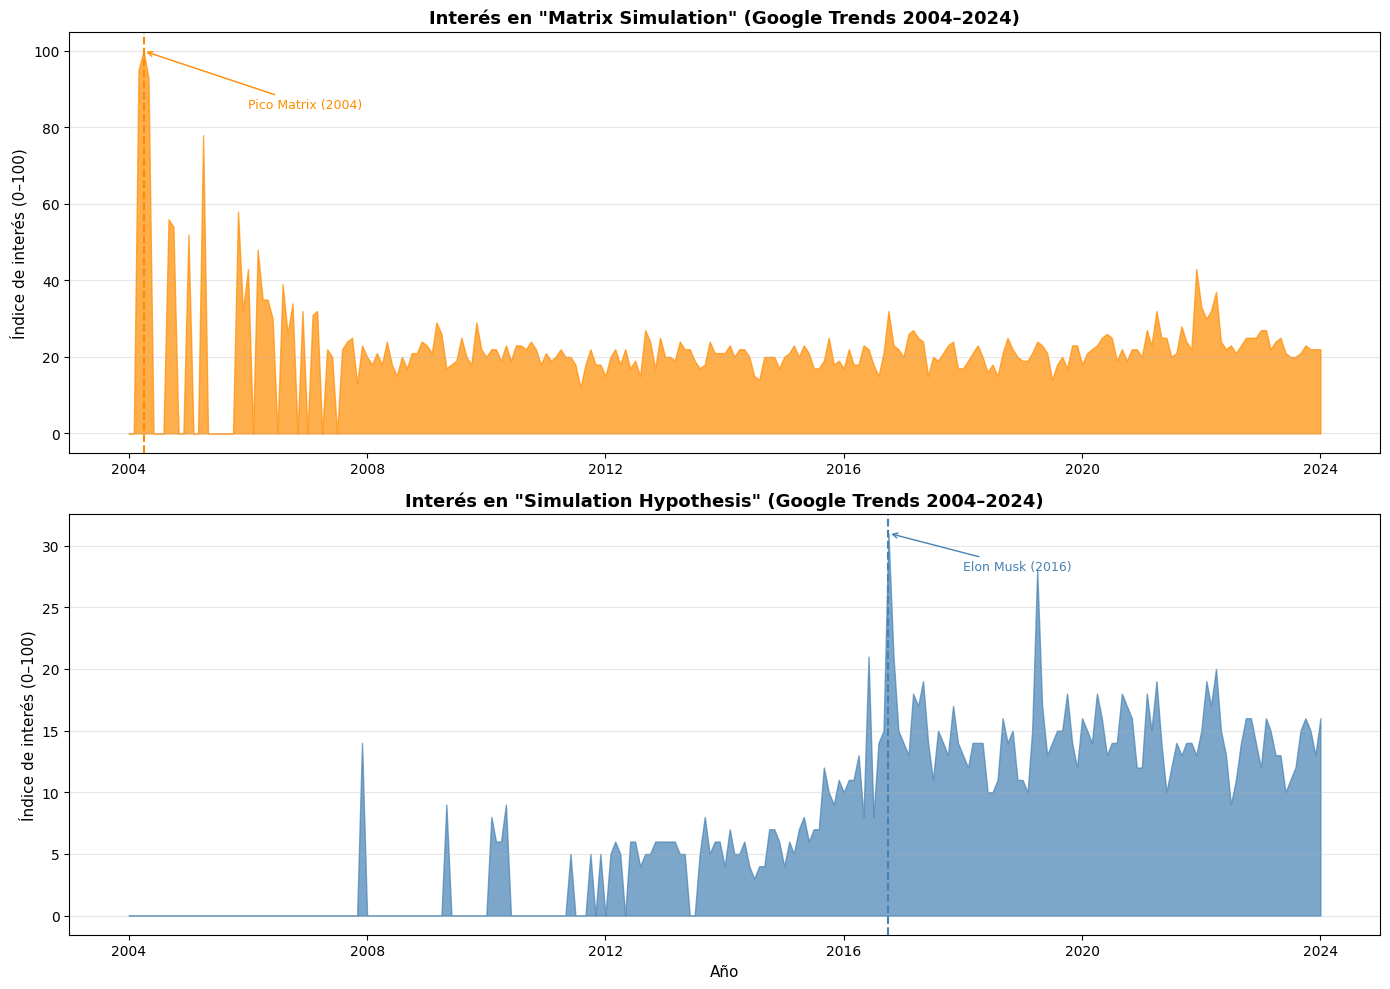

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# --- Gráfico 1: Matrix simulation ---
ax1.fill_between(df_trends.index, df_trends['Matrix simulation'], alpha=0.7, color='darkorange')
ax1.axvline(pd.Timestamp('2004-04-01'), color='darkorange', linestyle='--', linewidth=1.5)
ax1.annotate('Pico Matrix (2004)', xy=(pd.Timestamp('2004-04-01'), 100),
            xytext=(pd.Timestamp('2006-01-01'), 85),
            arrowprops=dict(arrowstyle='->', color='darkorange'),
            fontsize=9, color='darkorange')
ax1.set_title('Interés en "Matrix Simulation" (Google Trends 2004–2024)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Índice de interés (0–100)', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Gráfico 2: Simulation hypothesis ---
ax2.fill_between(df_trends.index, df_trends['simulation hypothesis'], alpha=0.7, color='steelblue')
ax2.axvline(pd.Timestamp('2016-10-01'), color='steelblue', linestyle='--', linewidth=1.5)
ax2.annotate('Elon Musk (2016)', xy=(pd.Timestamp('2016-10-01'), 31),
            xytext=(pd.Timestamp('2018-01-01'), 28),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            fontsize=9, color='steelblue')
ax2.set_title('Interés en "Simulation Hypothesis" (Google Trends 2004–2024)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Año', fontsize=11)
ax2.set_ylabel('Índice de interés (0–100)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## Conclusiones Hipótesis 2

Los datos de Google Trends muestran que el interés por la Teoría de la Simulación ha sido constante durante 
las dos últimas décadas, con "Matrix Simulation" manteniendo un nivel de búsqueda sostenido desde 2004 y 
"Simulation Hypothesis" creciendo de forma notable a partir de 2016 tras las declaraciones virales de Elon Musk.

Sin embargo, hay que ser honestos con las limitaciones del análisis. Google Trends solo ofrece datos desde 2004, 
cinco años después del estreno de *The Matrix*, por lo que no podemos demostrar directamente que fue la saga 
quien originó el interés popular por esta teoría. Tampoco podemos establecer causalidad, solo correlación.

Lo que sí podemos afirmar es que *The Matrix* mantuvo vivo el debate durante décadas y que el término 
"Matrix Simulation" sigue generando búsquedas constantes 25 años después de su estreno. La hipótesis es 
plausible y está bien apoyada, pero con esta limitación reconocida.